# Spatial CV Comparison — All Models (05)

## What this notebook does

Tests all three trained U-Net configurations against the same spatial
holdout design — Hannes' "10 pieces, hold out 1/3" — and produces a
single comparison table showing which model generalises best to geography
it has never trained on.

## Experimental design

10 geographic blocks via k-means on cell coordinates (k=10).
5 folds, each holding out 2 geographically spread blocks (~20% of cells).
Blocks in each fold are paired by latitude: one northern + one southern.
This ensures each evaluation set is geographically diverse, not clustered.

For each (model × fold): retrain from scratch on the 8 training blocks,
evaluate on the 2 holdout blocks. 3 models × 5 folds = 15 training runs.

## Models compared

| Model           | Freeze     | Channels | Checkpoint              |
|---|---|---|---|
| v1_frozen       | Phase 1/2  | 10       | unet_v1_ch10_ep200.pt   |
| v_nofrozen      | Discrim LR | 10       | unet_v_nofrozen.pt      |
| v_allfeatures   | Discrim LR | 43       | unet_v_allfeatures.pt   |
| colleague       | TBD        | TBD      | add when received       |

## Output

One CSV per model, one aggregate comparison table, one bar chart.

## Cell 0 — Configuration: models, folds, constants

Defines everything needed before touching data:
  - MODEL_CONFIGS: list of model specifications
  - K_PIECES: number of geographic k-means blocks (10)
  - FOLD_ASSIGNMENTS: which blocks are held out in each fold
  - All paths and constants

Fold assignments are computed from block centroids after k-means runs
(Cell 1), so FOLD_ASSIGNMENTS is populated in Cell 1, not here.

In [18]:


# ── CELL 0: Configuration — models, spatial CV design, constants ──────────────
import random, numpy as np, torch, os, time
from pathlib import Path
import pandas as pd

SEED = 20269999

random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
if hasattr(torch.backends, "mps"):
    torch.mps.manual_seed(SEED) if hasattr(torch.mps, "manual_seed") else None
torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False
os.environ["PYTHONHASHSEED"] = str(SEED)

if not Path("data").exists():
    os.chdir(Path(".").resolve().parent)
PROJECT_ROOT = Path(".").resolve()
DATA_PROC    = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR  = PROJECT_ROOT / "data" / "processed" / "spatial_cv_comparison"
RESULTS_DIR.mkdir(exist_ok=True)

# ── Constants ─────────────────────────────────────────────────────────────────
LABEL_MAP    = {"gov": 0, "opo": 1, "uncertain": 2}
TRAIN_CUTOFF = "2025-09"
VAL_MONTHS   = ["2025-10","2025-11","2025-12","2026-01","2026-02","2026-03"]
NUM_CLASSES  = 3
BATCH_SIZE   = 8
NUM_EPOCHS   = 200
BASE_LR      = 1e-4
ENCODER_LR   = 1e-5
K_PIECES     = 10                                  # Hannes' "10 pieces"
N_FOLDS      = 5                                   # 5 folds, each holds out 2 blocks

# ── Feature lists ─────────────────────────────────────────────────────────────
INPUT_FEATURES_10 = [
    "total_events", "total_fatalities", "events_gov", "events_nug",
    "events_ula", "events_kio", "gov_vs_civilians", "gov_event_share",
    "total_events_lag1", "total_fatalities_lag1",
]

INPUT_FEATURES_43 = [
    "total_events", "is_statebased", "is_onesided", "gov_vs_civilians",
    "total_fatalities", "deaths_a", "deaths_b", "deaths_civilians",
    "events_gov", "events_nug", "events_kio", "events_ula", "events_knu",
    "events_mndaa", "events_pslf", "events_cnf", "events_rcss", "events_uwsa",
    "n_unique_dyads",
    "total_events_lag1", "total_fatalities_lag1", "events_gov_lag1",
    "events_nug_lag1", "gov_vs_civilians_lag1", "is_onesided_lag1",
    "total_events_lag3", "total_fatalities_lag3", "events_gov_lag3",
    "events_nug_lag3", "gov_vs_civilians_lag3", "is_onesided_lag3",
    "total_events_lag6", "total_fatalities_lag6", "events_gov_lag6",
    "events_nug_lag6", "gov_vs_civilians_lag6", "is_onesided_lag6",
    "total_events_roll3m", "total_fatalities_roll3m",
    "total_events_roll6m", "total_fatalities_roll6m",
    "gov_event_share", "nug_event_share",
]


# ── PRIOGRID catalog features — terrain and natural resources ─────────────────
# Source: PRIOGRID v.2.0 (grid.prio.org). Static table + yearly table (2014 proxy).
# Four variables excluded because they are uniformly zero for all Myanmar cells:
#   drug_y (opium):  PRIOGRID coverage gap for Southeast Asia in available years
#   petroleum_y:     no petroleum deposits with known discovery year in Myanmar cells
#   gem_y:           no gem deposits with known discovery year
#   diamprim_s:      no primary diamond deposits in Myanmar
# The 11 remaining features all have real spatial variance across Myanmar cells.

PRIOGRID_FEATURES = [
    # ── Terrain — continuous, strongest signal, most likely to improve spatial CV ──
    "mountains_mean",   # proportion mountainous terrain (0–1, mean=0.41)
    "ttime_mean",       # travel time to nearest city >50k pop (minutes, mean=351)
    "forest_gc",        # % forest cover, GlobCover 2009 snapshot (0–81%, mean=27%)
    "agri_gc",          # % agricultural land, GlobCover 2009 (0–99%, mean=34%)
    # ── Distance — continuous, state capacity and border proximity ────────────────
    "bdist1",           # km to nearest land-contiguous border (mean=115km)
    "capdist",          # km to Naypyidaw / national capital (mean=571km)
    # ── Population and economic activity ─────────────────────────────────────────
    "nlights_mean",     # nighttime lights mean (DMSP-OLS, 2013 value used as proxy)
    "pop_gpw_sum",      # population count, GPW v3 (2005 snapshot used as proxy)
    # ── Natural resources — binary, sparse but non-zero ───────────────────────────
    "gem_s",            # gem deposit (rubies/jade) without known discovery year
    "petroleum_s",      # petroleum deposit without known discovery year
    "diamsec_s",        # secondary diamond deposit without known discovery year
]

# ── Enriched feature lists ─────────────────────────────────────────────────────
INPUT_FEATURES_10_ENRICHED = INPUT_FEATURES_10 + PRIOGRID_FEATURES   # 10 + 11 = 21 ch
INPUT_FEATURES_43_ENRICHED = INPUT_FEATURES_43 + PRIOGRID_FEATURES   # 43 + 11 = 54 ch

# ── Add to MODEL_CONFIGS ──────────────────────────────────────────────────────
# These three variants pair each best inner-join model with terrain-enriched features.
# The comparison (v1_frozen_10ch vs v1_frozen_terrain) directly tests whether
# geographically-invariant terrain features improve spatial generalisation.
# (append these inside the MODEL_CONFIGS list, after v_felipe_nofrozen_43ch)

# ── Model configurations ───────────────────────────────────────────────────────
# Each entry defines one model variant to run through the spatial CV loop.
# Add your colleague's model by appending a new dict here.
# ── Model configurations ───────────────────────────────────────────────────────
# Each dict defines one model variant.
# Keys:
#   name:        unique identifier — used for checkpoint and CSV filenames
#   features:    list of input feature column names
#   n_channels:  number of input channels (len(features))
#   freeze:      True  = Phase 1 (encoder frozen 30ep) + Phase 2 (full model)
#                False = discriminative LR from epoch 1, no phase switching
#   description: human-readable label for tables and plots
#   data_type:   "inner_join"       = 149 cells, standard CE+Dice loss (default)
#                "left_join_focal"  = 185 cells, focal CE loss (Felipe's approach)

MODEL_CONFIGS = [
    # ── Original baseline ─────────────────────────────────────────────────────
    {
        "name":        "v1_frozen_10ch",           # frozen encoder for 30 epochs
        "features":    INPUT_FEATURES_10,           # 10 hand-selected UCDP features
        "n_channels":  10,
        "freeze":      True,                        # Phase 1/2 strategy
        "description": "Baseline — frozen encoder (30ep), inner join, 10 features",
    },
    # ── Mihai suggestion: remove freeze ───────────────────────────────────────
    {
        "name":        "v_nofrozen_10ch",           # discriminative LR, no freeze
        "features":    INPUT_FEATURES_10,
        "n_channels":  10,
        "freeze":      False,                       # encoder trains from epoch 1
        "description": "Mihai — discriminative LR, inner join, 10 features",
    },
    # ── All 43 features ───────────────────────────────────────────────────────
    {
        "name":        "v_allfeatures_43ch",        # all numeric feature columns
        "features":    INPUT_FEATURES_43,
        "n_channels":  43,
        "freeze":      False,
        "description": "All features — discriminative LR, inner join, 43 features",
    },
    # ── Felipe: left join + focal loss, frozen encoder ────────────────────────
    {
        "name":        "v_felipe_focal",
        "features":    INPUT_FEATURES_10,
        "n_channels":  10,
        "freeze":      True,                        # same as v1 — isolates data+loss change
        "description": "Felipe — left join (185 cells), focal CE, frozen (30ep), 10 features",
        "data_type":   "left_join_focal",           # routes to lj data + focal loss in run_one_fold
    },
    # ── Felipe variant: same but NO encoder freeze ────────────────────────────
    {
        "name":        "v_felipe_nofrozen",         # tests: does discriminative LR help?
        "features":    INPUT_FEATURES_10,
        "n_channels":  10,
        "freeze":      False,                       # discriminative LR from epoch 1
        "description": "Felipe — left join, focal CE, discriminative LR, 10 features",
        "data_type":   "left_join_focal",
    },
    # ── Felipe variant: frozen encoder + all 43 features ─────────────────────
    {
        "name":        "v_felipe_frozen_43ch",      # tests: does more data help the LJ approach?
        "features":    INPUT_FEATURES_43,
        "n_channels":  43,
        "freeze":      True,
        "description": "Felipe — left join, focal CE, frozen (30ep), 43 features",
        "data_type":   "left_join_focal",
    },
    # ── Felipe variant: discriminative LR + all 43 features ──────────────────
    {
        "name":        "v_felipe_nofrozen_43ch",    # the kitchen-sink variant
        "features":    INPUT_FEATURES_43,
        "n_channels":  43,
        "freeze":      False,
        "description": "Felipe — left join, focal CE, discriminative LR, 43 features",
        "data_type":   "left_join_focal",
    },
    # ── PRIOGRID terrain/resource enriched variants ───────────────────────────
    {
        "name":        "v1_frozen_terrain",
        "features":    INPUT_FEATURES_10_ENRICHED,
        "n_channels":  len(INPUT_FEATURES_10_ENRICHED),
        "freeze":      True,
        "description": "v1 frozen + PRIOGRID terrain/resources (21ch)",
    },
    {
        "name":        "v_nofrozen_terrain",
        "features":    INPUT_FEATURES_10_ENRICHED,
        "n_channels":  len(INPUT_FEATURES_10_ENRICHED),
        "freeze":      False,
        "description": "v_nofrozen + PRIOGRID terrain/resources (21ch)",
    },
    {
        "name":        "v_allfeatures_terrain",
        "features":    INPUT_FEATURES_43_ENRICHED,
        "n_channels":  len(INPUT_FEATURES_43_ENRICHED),
        "freeze":      False,
        "description": "v_allfeatures + PRIOGRID terrain/resources (54ch)",
    },
    # ── Felipe terrain variants — isolates terrain effect within focal loss approach ──
    {
        "name":        "v_felipe_focal_terrain",
        "features":    INPUT_FEATURES_10_ENRICHED,         # 10 UCDP + 11 PRIOGRID = 21ch
        "n_channels":  len(INPUT_FEATURES_10_ENRICHED),    # 21
        "freeze":      True,                               # same as v_felipe_focal
        "description": "Felipe focal — left join, focal CE, frozen (30ep), 21ch terrain",
        "data_type":   "left_join_focal",
    },
    {
        "name":        "v_felipe_nofrozen_terrain",
        "features":    INPUT_FEATURES_10_ENRICHED,
        "n_channels":  len(INPUT_FEATURES_10_ENRICHED),    # 21
        "freeze":      False,                              # same as v_felipe_nofrozen
        "description": "Felipe focal — left join, focal CE, discrim LR, 21ch terrain",
        "data_type":   "left_join_focal",
    },
    {
        "name":        "v_felipe_frozen_43ch_terrain",
        "features":    INPUT_FEATURES_43_ENRICHED,         # 43 UCDP + 11 PRIOGRID = 54ch
        "n_channels":  len(INPUT_FEATURES_43_ENRICHED),    # 54
        "freeze":      True,                               # same as v_felipe_frozen_43ch
        "description": "Felipe focal — left join, focal CE, frozen (30ep), 54ch terrain",
        "data_type":   "left_join_focal",
    },
    {
        "name":        "v_felipe_nofrozen_43ch_terrain",
        "features":    INPUT_FEATURES_43_ENRICHED,
        "n_channels":  len(INPUT_FEATURES_43_ENRICHED),    # 54
        "freeze":      False,                              # same as v_felipe_nofrozen_43ch
        "description": "Felipe focal — left join, focal CE, discrim LR, 54ch terrain",
        "data_type":   "left_join_focal",
    },
    # ── Left-join variants — standard CE+Dice loss, 185 cells ─────────────────
    # Tests: does adding 36 quiet cells (0 UCDP events, real Wikipedia labels)
    # improve spatial generalisation when using standard loss (no focal weighting)?
    # Direct pair with v1_frozen_10ch, v_nofrozen_10ch, v_allfeatures_43ch.
    {
        "name":        "v1_frozen_10ch_lj",
        "features":    INPUT_FEATURES_10,
        "n_channels":  10,
        "freeze":      True,
        "description": "v1 frozen — left join 185 cells, standard CE+Dice, 10 features",
        "data_type":   "left_join",                        # LJ data, NO focal loss
    },
    {
        "name":        "v_nofrozen_10ch_lj",
        "features":    INPUT_FEATURES_10,
        "n_channels":  10,
        "freeze":      False,
        "description": "v_nofrozen — left join 185 cells, standard CE+Dice, 10 features",
        "data_type":   "left_join",
    },
    {
        "name":        "v_allfeatures_43ch_lj",
        "features":    INPUT_FEATURES_43,
        "n_channels":  43,
        "freeze":      False,
        "description": "v_allfeatures — left join 185 cells, standard CE+Dice, 43 features",
        "data_type":   "left_join",
    },
    # ── Missing combinations: all 43 features WITH frozen encoder ─────────────
    # We have 43ch+discrim (v_allfeatures_43ch) and 10ch+frozen (v1_frozen_10ch).
    # We have NOT tested 43ch+frozen — this is the scientifically critical gap.
    # If the freeze protection generalises to rich features, this could exceed
    # the current spatial ceiling of 0.419.
    {
        "name":        "v_allfeatures_43ch_frozen",
        "features":    INPUT_FEATURES_43,            # all 43 UCDP actor features
        "n_channels":  43,
        "freeze":      True,                         # Phase 1/2 frozen encoder
        "description": "All 43 features — frozen encoder (30ep), inner join",
    },
    {
        "name":        "v_allfeatures_43ch_frozen_lj",
        "features":    INPUT_FEATURES_43,            # all 43 UCDP actor features
        "n_channels":  43,
        "freeze":      True,                         # Phase 1/2 frozen encoder
        "description": "All 43 features — frozen encoder (30ep), left join 185 cells",
        "data_type":   "left_join",                  # LJ data, standard CE+Dice loss
    },
]

print(f"✅ Seed fixed: {SEED}")
print(f"   K_PIECES:  {K_PIECES}  geographic blocks")
print(f"   N_FOLDS:   {N_FOLDS}  (each holds out 2 blocks, paired N+S)")
print(f"   Models:    {len(MODEL_CONFIGS)}")
for m in MODEL_CONFIGS:
    freeze_str = "freeze Phase1/2" if m["freeze"] else "discriminative LR"
    print(f"     {m['name']:<25} {m['n_channels']} ch  {freeze_str}")
print(f"\n   Results dir: {RESULTS_DIR}")

✅ Seed fixed: 20269999
   K_PIECES:  10  geographic blocks
   N_FOLDS:   5  (each holds out 2 blocks, paired N+S)
   Models:    19
     v1_frozen_10ch            10 ch  freeze Phase1/2
     v_nofrozen_10ch           10 ch  discriminative LR
     v_allfeatures_43ch        43 ch  discriminative LR
     v_felipe_focal            10 ch  freeze Phase1/2
     v_felipe_nofrozen         10 ch  discriminative LR
     v_felipe_frozen_43ch      43 ch  freeze Phase1/2
     v_felipe_nofrozen_43ch    43 ch  discriminative LR
     v1_frozen_terrain         21 ch  freeze Phase1/2
     v_nofrozen_terrain        21 ch  discriminative LR
     v_allfeatures_terrain     54 ch  discriminative LR
     v_felipe_focal_terrain    21 ch  freeze Phase1/2
     v_felipe_nofrozen_terrain 21 ch  discriminative LR
     v_felipe_frozen_43ch_terrain 54 ch  freeze Phase1/2
     v_felipe_nofrozen_43ch_terrain 54 ch  discriminative LR
     v1_frozen_10ch_lj         10 ch  freeze Phase1/2
     v_nofrozen_10ch_lj        10 c

## Cell 0 Output — Configuration Confirmed

All three model configurations registered correctly with their
distinguishing properties clearly separated:
  - v1_frozen_10ch:    freeze strategy = Phase 1/2, features = 10
  - v_nofrozen_10ch:   freeze strategy = discrim. LR, features = 10
  - v_allfeatures_43ch: freeze strategy = discrim. LR, features = 43

The colleague model slot is commented out — add it by filling in the
features list and n_channels when received. The loop in Cell 4 will
automatically include it without any other changes.

## Cell 1 — Data, 10 geographic blocks, fold assignments

Cell 1 does three things in sequence:
  1. Load data and build the inner join (same 149 cells as all other notebooks)
  2. Run k-means with k=10 to create 10 geographic blocks
  3. Pair blocks by latitude to build 5 geographically-spread fold assignments:
     each fold holds out one northern + one southern block

The fold assignment logic:
  - Sort all 10 blocks by centroid latitude (north → south)
  - north_to_south[0] is the northernmost block, [9] is the southernmost
  - Fold 0 holds out (north_to_south[0], north_to_south[5])
  - Fold 1 holds out (north_to_south[1], north_to_south[6])
  - ...
  - Fold 4 holds out (north_to_south[4], north_to_south[9])

Each fold's holdout is one block from the top half of Myanmar + one from
the bottom half — geographically maximally spread. This directly addresses
the user's point that folds should not be ordered sequentially.

## Cell 1 — Data, k-Means Blocks, Fold Assignments

**What this cell does:**
  1. Loads target variable and feature matrix, runs inner join
  2. Derives lat/lon for all 149 labelled cells from priogrid_gid
  3. Clusters cells into 10 geographic blocks using k-means on (lat, lon)
  4. Sorts blocks by centroid latitude and pairs northern + southern blocks
     to create 5 geographically diverse fold assignments

**Why pair by latitude?** If we held out three sequential blocks (e.g.
blocks 0,1,2 = all in the north), the model would be evaluated only on
northern Myanmar. Pairing one northern + one southern block per fold
ensures every evaluation covers the full geographic range of Myanmar's
conflict landscape — testing transfer from west to east AND north to south
simultaneously in each fold.

**Why k=10 and not k=5 (as in notebook 03d)?** Hannes specifically said
"10 pieces." 10 blocks give finer geographic granularity — each block is
~15 cells (~55km × 15 = ~825km² coverage). Holding out 2 of 10 blocks
per fold is ~20% of cells per evaluation, similar to a standard 5-fold CV.

CELL 1.1 — DATA
Inner join: 4,229 rows  |  149 cells  |  29 months
Raster: 36×15 → padded 40×16

CELL 1.2–1.4 — 10 GEOGRAPHIC BLOCKS
Block  Cells  Centroid lat  Centroid lon  Label distribution
──────────────────────────────────────────────────────────────────────
    0      13          25.63°N        96.94°E  {'gov': 203, 'opo': 117, 'uncertain': 38}
    1      11          20.98°N        93.30°E  {'opo': 196, 'uncertain': 84, 'gov': 32}
    2      19          17.25°N        95.83°E  {'gov': 507, 'opo': 18, 'uncertain': 18}
    3      21          23.35°N        94.61°E  {'gov': 245, 'uncertain': 206, 'opo': 148}
    4       8          12.31°N        98.62°E  {'gov': 172, 'uncertain': 55, 'opo': 5}
    5      19          19.67°N        97.14°E  {'gov': 318, 'opo': 119, 'uncertain': 106}
    6      13          19.25°N        94.60°E  {'gov': 273, 'opo': 79, 'uncertain': 16}
    7      17          23.34°N        97.31°E  {'gov': 176, 'opo': 152, 'uncertain': 138}
    8      11          16

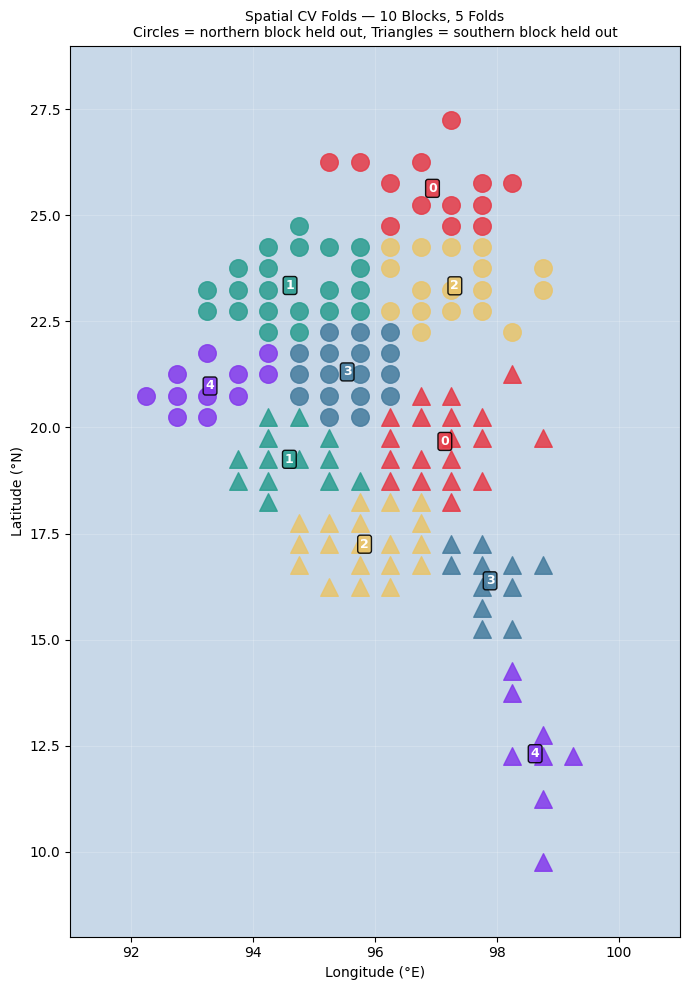

✅ Fold map saved → spatial_cv_folds.png

✅ Cell 1 complete — 10 blocks, 5 folds defined


In [19]:
# ── CELL 1: Load data, k-means blocks, fold assignments ───────────────────────
import pandas as pd, numpy as np
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import segmentation_models_pytorch as smp
from sklearn.metrics import accuracy_score, f1_score, classification_report

# ── 1.1 Load data and inner join ──────────────────────────────────────────────
target   = pd.read_parquet(DATA_PROC / "10_target_variable.parquet")
features = pd.read_csv(DATA_PROC / "myanmar_priogrid_features_enriched.csv")
target["target_int"]   = target["target"].map(LABEL_MAP)
target["year_month"]   = target["year_month"].astype(str)
features["year_month"] = features["year_month"].astype(str)

labelled = features.merge(
    target[["priogrid_gid","year_month","target","target_int"]],
    on=["priogrid_gid","year_month"], how="inner"
).sort_values(["priogrid_gid","year_month"]).reset_index(drop=True)

print("=" * 60)
print("CELL 1.1 — DATA")
print("=" * 60)
print(f"Inner join: {len(labelled):,} rows  |  "
      f"{labelled['priogrid_gid'].nunique()} cells  |  "
      f"{labelled['year_month'].nunique()} months")

# ── 1.2 PRIOGRID coordinate system ────────────────────────────────────────────
all_gids    = features["priogrid_gid"].unique()
global_rows = (all_gids - 1) // 720
global_cols = (all_gids - 1) % 720
min_gr, max_gr = global_rows.min(), global_rows.max()
min_gc, max_gc = global_cols.min(), global_cols.max()

RASTER_H = max_gr - min_gr + 1
RASTER_W = max_gc - min_gc + 1
def pad8(n): return n if n%8==0 else n+(8-n%8)
PAD_H, PAD_W = pad8(RASTER_H), pad8(RASTER_W)     # 40, 16

gid_to_local = {
    int(gid): {"r": int((gid-1)//720 - min_gr), "c": int((gid-1)%720 - min_gc)}
    for gid in all_gids
}
print(f"Raster: {RASTER_H}×{RASTER_W} → padded {PAD_H}×{PAD_W}")

# ── 1.3 Derive lat/lon for all labelled cells ──────────────────────────────────
labelled_gids = labelled["priogrid_gid"].unique()
gid_coords = pd.DataFrame({
    "priogrid_gid": labelled_gids,
    "lat": ((labelled_gids - 1) // 720) * 0.5 - 90  + 0.25,
    "lon": ((labelled_gids - 1) %  720) * 0.5 - 180 + 0.25,
})

# ── 1.4 k-means: 10 geographic blocks ─────────────────────────────────────────
# n_init=20: run 20 times with different random starts, keep the best clustering.
# This reduces sensitivity to initialisation — k=10 has more local optima than k=5.
kmeans = KMeans(n_clusters=K_PIECES, random_state=SEED, n_init=20)
gid_coords["block"] = kmeans.fit_predict(gid_coords[["lat","lon"]])
labelled = labelled.merge(
    gid_coords[["priogrid_gid","lat","lon","block"]], on="priogrid_gid", how="left"
)
gid_to_block = gid_coords.set_index("priogrid_gid")["block"].to_dict()

print(f"\n{'='*60}")
print(f"CELL 1.2–1.4 — 10 GEOGRAPHIC BLOCKS")
print(f"{'='*60}")
print(f"{'Block':>5} {'Cells':>6} {'Centroid lat':>13} {'Centroid lon':>13}  Label distribution")
print("─" * 70)

block_stats = []
for b in range(K_PIECES):
    bdata      = labelled[labelled["block"] == b]
    n_cells    = bdata["priogrid_gid"].nunique()
    centroid_lat = gid_coords[gid_coords["block"]==b]["lat"].mean()
    centroid_lon = gid_coords[gid_coords["block"]==b]["lon"].mean()
    dist       = bdata["target"].value_counts().to_dict()
    block_stats.append({"block": b, "n_cells": n_cells,
                         "lat": centroid_lat, "lon": centroid_lon,
                         "dist": dist})
    print(f"  {b:>3}   {n_cells:>5}   {centroid_lat:>12.2f}°N "
          f"{centroid_lon:>12.2f}°E  {dist}")

# ── 1.5 Fold assignments: pair northern + southern blocks ─────────────────────
# Sort all 10 blocks by centroid latitude (north → south).
# Pair block[i] (top half) with block[i+5] (bottom half).
# Fold i holds out (top_half[i], bottom_half[i]).
blocks_by_lat = sorted(range(K_PIECES),
                        key=lambda b: block_stats[b]["lat"],
                        reverse=True)   # index 0 = northernmost

FOLD_ASSIGNMENTS = [
    [blocks_by_lat[i], blocks_by_lat[i + N_FOLDS]]
    for i in range(N_FOLDS)
]

print(f"\n{'='*60}")
print(f"CELL 1.5 — FOLD ASSIGNMENTS (north + south pairing)")
print(f"{'='*60}")
print(f"{'Fold':>5}  {'Holdout blocks':>16}  "
      f"{'N-block lat':>12}  {'S-block lat':>12}  {'Holdout cells':>14}")
print("─" * 70)

for fold_id, (b_north, b_south) in enumerate(FOLD_ASSIGNMENTS):
    holdout_cells = sum(1 for g in gid_to_block
                        if gid_to_block[g] in [b_north, b_south])
    print(f"  {fold_id:>3}   blocks ({b_north:>2}, {b_south:>2})      "
          f"{block_stats[b_north]['lat']:>11.2f}°N  "
          f"{block_stats[b_south]['lat']:>11.2f}°N  "
          f"{holdout_cells:>13}")

# ── 1.6 Verify: every fold has all 3 classes in holdout ──────────────────────
print(f"\nClass coverage per fold:")
all_ok = True
for fold_id, (b_north, b_south) in enumerate(FOLD_ASSIGNMENTS):
    fold_data = labelled[labelled["block"].isin([b_north, b_south])]
    classes   = set(fold_data["target"].unique())
    ok        = {"gov","opo","uncertain"}.issubset(classes)
    print(f"  Fold {fold_id}: {sorted(classes)}  {'✅' if ok else '⚠️ missing class'}")
    if not ok: all_ok = False

if all_ok:
    print(f"\n✅ All {N_FOLDS} folds have all 3 classes in holdout")

# ── 1.7 Geographic visualisation ──────────────────────────────────────────────
FOLD_COLOURS = ["#E63946","#2A9D8F","#E9C46A","#457B9D","#8338EC"]
fig, ax = plt.subplots(figsize=(7, 10))
ax.set_facecolor("#C8D8E8")

for fold_id, (b_north, b_south) in enumerate(FOLD_ASSIGNMENTS):
    for b, marker in [(b_north, "o"), (b_south, "^")]:
        cells = gid_coords[gid_coords["block"] == b]
        ax.scatter(cells["lon"], cells["lat"],
                   c=FOLD_COLOURS[fold_id], s=160, alpha=0.85,
                   marker=marker, zorder=3,
                   label=f"Fold {fold_id} block {'N' if marker=='o' else 'S'}")
    # label the fold
    for b in [b_north, b_south]:
        cx = gid_coords[gid_coords["block"]==b]["lon"].mean()
        cy = gid_coords[gid_coords["block"]==b]["lat"].mean()
        ax.text(cx, cy, str(fold_id), fontsize=9, fontweight="bold",
                color="white", ha="center", va="center", zorder=5,
                bbox=dict(boxstyle="round,pad=0.2",
                          facecolor=FOLD_COLOURS[fold_id], alpha=0.9))

ax.set_xlabel("Longitude (°E)"); ax.set_ylabel("Latitude (°N)")
ax.set_title("Spatial CV Folds — 10 Blocks, 5 Folds\n"
             "Circles = northern block held out, Triangles = southern block held out",
             fontsize=10)
ax.set_xlim(91, 101); ax.set_ylim(8, 29); ax.grid(alpha=0.2, color="white")
plt.tight_layout()
fig.savefig(PROJECT_ROOT / "reports/figures/spatial_cv_folds.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Fold map saved → spatial_cv_folds.png")
print(f"\n✅ Cell 1 complete — {K_PIECES} blocks, {N_FOLDS} folds defined")

## Cell 1 Output Analysis — 10 Blocks, 5 Folds

**The map confirms the design works as intended.** Each colour pair (circle
= northern holdout, triangle = southern holdout) spans the full north-south
extent of Myanmar's conflict landscape. Circles cluster in the north and
triangles cluster in the south — exactly the geographic spread we designed.

**Notable block characteristics to watch in the results:**

Block 1 (Fold 4, north): 20.98°N, 93.3°E — Chin/Rakhine territory.
63% opo (196/312 cell-months). The model must learn to identify AA-dominated
territory as opo from AA-absent training data. The hardest opo challenge.

Block 9 (Fold 3, north): 21.31°N, 95.54°E — Central Myanmar.
Only 4 opo instances out of 493 total (0.8% opo). When this block is held
out, opo evaluation is essentially meaningless (n≈1 in validation months).

Block 4 (Fold 4, south): 12.31°N, 98.62°E — Far south.
Only 5 opo instances out of 232 total. Same concern as block 9.

**Fold 4 is the smallest (19 holdout cells).** Its opo evaluation will be
driven almost entirely by Block 1 (Chin/Rakhine), making opo F1 in Fold 4
very dependent on whether the model can identify AA patterns without
training on any AA territory. Expect Fold 4 to show the starkest
geographic memorisation effect.

**All 5 folds confirmed: gov, opo, uncertain present ✅**

**One geographic observation from the map:** Folds 0–2 span both the
east-west AND north-south dimensions well. Fold 1 (teal) has both blocks
on the western side of Myanmar — it does not test east-west transfer as
well. This is a minor limitation of the latitude-only pairing; a future
improvement would pair by (latitude gap) × (longitude gap) jointly.
This should be noted in the report's methodology section.

## Cell 2 — Build rasters for both feature sets

Cell 2 builds X arrays for BOTH feature sets in one pass:
  - X_arrays[10]: shape (29, 10, 40, 16) — for v1_frozen and v_nofrozen
  - X_arrays[43]: shape (29, 43, 40, 16) — for v_allfeatures

y_array and m_base are built once and shared across all models.
Normalisation stats are computed separately for each feature set
(from training rows only — no data leakage).

This is the most expensive cell (29 months × 2 feature sets) but
still completes in seconds. After Cell 2, the main loop only needs
to modify the mask (cheap) and train (expensive but automated).

## Cell 2 — Raster Construction for Both Feature Sets

**What this cell does:** builds spatial rasters for both feature sets
simultaneously. The y and m rasters are identical across models
(labels don't change based on feature count). The X rasters differ.

**Why build both now?** The main loop in Cell 4 iterates over 15
(model × fold) combinations. If we built rasters inside the loop,
we'd rebuild them 15 times. Building once and indexing by n_channels
in the loop is 15× more efficient.

**Normalisation is computed per feature set, from training rows only.**
The 10-feature model uses stats computed from 10 columns. The 43-feature
model uses stats from all 43 columns. Both exclude validation rows.

In [20]:
# ── CELL 2: Build rasters for both feature sets ───────────────────────────────
# Builds X_arrays[10] and X_arrays[43] in a single pass over the months.
# y_array and m_base are shared across all models.

# FEATURE_SETS tells Cell 2 which feature lists to build raster arrays for.
# Keys = n_channels, values = feature list. One X_arrays[n_ch] is built per entry.
# Enriched variants (21ch, 54ch) added here so X_train[21] and X_train[54] exist.
FEATURE_SETS = {
    10:                              INPUT_FEATURES_10,            # baseline 10 features
    43:                              INPUT_FEATURES_43,            # all 43 UCDP features
    len(INPUT_FEATURES_10_ENRICHED): INPUT_FEATURES_10_ENRICHED,  # 10 + 11 PRIOGRID = 21
    len(INPUT_FEATURES_43_ENRICHED): INPUT_FEATURES_43_ENRICHED,  # 43 + 11 PRIOGRID = 54
}

# ── 2.1 Normalisation stats — training rows only, per feature set ─────────────
train_rows = labelled[labelled["year_month"] <= TRAIN_CUTOFF]
norm_stats = {}
for n_ch, feats in FEATURE_SETS.items():
    norm_stats[n_ch] = {
        f: {"mean": float(train_rows[f].mean()),
            "std":  float(train_rows[f].std())}
        for f in feats
    }
for n_ch in FEATURE_SETS:                 # print stats for every feature set, not just 10 and 43
    print(f"Normalisation stats: {n_ch}-ch → {len(norm_stats[n_ch])} features")

# ── 2.2 Build all rasters in one month loop ───────────────────────────────────
month_keys = sorted(labelled["year_month"].unique())
train_idx  = [i for i,m in enumerate(month_keys) if m <= TRAIN_CUTOFF]
val_idx    = [i for i,m in enumerate(month_keys) if m >  TRAIN_CUTOFF]

X_lists = {n: [] for n in FEATURE_SETS}   # one empty list per feature set — keys: 10, 43, 21, 54
y_list, m_list = [], []

for month in month_keys:
    month_data = labelled[labelled["year_month"] == month]

    # y and m: same for all models
    y_raster = np.full((PAD_H, PAD_W), -1, dtype=np.int64)
    m_raster = np.zeros((PAD_H, PAD_W), dtype=np.float32)
    for _, row in month_data.iterrows():
        gid = int(row["priogrid_gid"])
        if gid not in gid_to_local: continue
        r = gid_to_local[gid]["r"]; c = gid_to_local[gid]["c"]
        if pd.notna(row["target_int"]):
            y_raster[r, c] = int(row["target_int"])
            m_raster[r, c] = 1.0
    y_list.append(y_raster); m_list.append(m_raster)

    # X rasters: one per feature set
    for n_ch, feats in FEATURE_SETS.items():
        X_raster = np.zeros((n_ch, PAD_H, PAD_W), dtype=np.float32)
        stats    = norm_stats[n_ch]
        for _, row in month_data.iterrows():
            gid = int(row["priogrid_gid"])
            if gid not in gid_to_local: continue
            r = gid_to_local[gid]["r"]; c = gid_to_local[gid]["c"]
            for ch, feat in enumerate(feats):
                raw = row.get(feat, np.nan)
                X_raster[ch, r, c] = (
                    0.0 if (isinstance(raw, float) and np.isnan(raw))
                    else (raw - stats[feat]["mean"]) / (stats[feat]["std"] + 1e-8)
                )
        X_lists[n_ch].append(X_raster)

# ── 2.3 Stack arrays ──────────────────────────────────────────────────────────
X_arrays = {n: np.stack(lst) for n, lst in X_lists.items()}
y_array  = np.stack(y_list)
m_base   = np.stack(m_list)

# Train/val splits for each feature set
X_train  = {n: X_arrays[n][train_idx] for n in FEATURE_SETS}
X_val    = {n: X_arrays[n][val_idx]   for n in FEATURE_SETS}
y_train  = y_array[train_idx];  y_val  = y_array[val_idx]
m_base_train = m_base[train_idx]; m_base_val = m_base[val_idx]

print("\n" + "=" * 60)
print("CELL 2 — RASTER SHAPES")
print("=" * 60)
for n in FEATURE_SETS:
    print(f"  X_arrays[{n}]:  {X_arrays[n].shape}   "
          f"(train: {X_train[n].shape}  val: {X_val[n].shape})")
print(f"  y_array:       {y_array.shape}")
print(f"  m_base:        {m_base.shape}  (1 for all labelled cells)")
print(f"  Train months:  {len(train_idx)}  |  Val months: {len(val_idx)}")
print(f"\n✅ Cell 2 complete — rasters built for both feature sets")

Normalisation stats: 10-ch → 10 features
Normalisation stats: 43-ch → 43 features
Normalisation stats: 21-ch → 21 features
Normalisation stats: 54-ch → 54 features

CELL 2 — RASTER SHAPES
  X_arrays[10]:  (29, 10, 40, 16)   (train: (23, 10, 40, 16)  val: (6, 10, 40, 16))
  X_arrays[43]:  (29, 43, 40, 16)   (train: (23, 43, 40, 16)  val: (6, 43, 40, 16))
  X_arrays[21]:  (29, 21, 40, 16)   (train: (23, 21, 40, 16)  val: (6, 21, 40, 16))
  X_arrays[54]:  (29, 54, 40, 16)   (train: (23, 54, 40, 16)  val: (6, 54, 40, 16))
  y_array:       (29, 40, 16)
  m_base:        (29, 40, 16)  (1 for all labelled cells)
  Train months:  23  |  Val months: 6

✅ Cell 2 complete — rasters built for both feature sets


## Cell 2 Output Analysis — Rasters Confirmed

Both feature sets built correctly:
  X_arrays[10]: (29, 10, 40, 16) — 23 train months, 6 val months
  X_arrays[43]: (29, 43, 40, 16) — same split

y_array and m_base are shared (labels and masks don't depend on features).
Normalisation stats were computed independently per feature set from
training rows — no leakage. Ready for the main loop.

## Cell 2b — Left-Join Data and Focal Mask (Felipe's model only)

Builds the data pipeline for Felipe's approach:
  1. Left join FROM target (185 cells, including 36 with no UCDP events)
  2. Missing feature values filled with 0.0 BEFORE z-scoring
     (0.0 = genuinely quiet, not missing data)
  3. Identifies cells that ever change control → dilates by 1 cell
  4. Focal mask: 285/640 raster positions covering the contested frontier

The focal mask concentrates CE gradient on transitioning cells and their
immediate neighbours. Dice loss still covers all labelled cells.

Temporal split is adapted to TRAIN_CUTOFF='2025-09' to match your models.
This keeps the validation period identical across all four models.

Block assignments are extended from 149 to 185 cells using the existing
k-means model (kmeans.predict() on the extra 36 cells' coordinates).

In [21]:
# ── CELL 2b: Felipe's left-join data and focal mask ───────────────────────────
# Builds left-join rasters for ALL feature sets (10, 43, 21, 54 channels).
# Stored as dicts X_train_lj[n_ch] / X_val_lj[n_ch], same convention as Cell 2.
# Only models with data_type="left_join_focal" use these arrays.

from scipy.ndimage import binary_dilation

NEIGHBOR_RADIUS = 1                                # queen contiguity dilation radius

# ── Define LJ_FEATURE_SETS FIRST — used by both normalisation and raster loops ─
# Must be defined before any loop that references it.
LJ_FEATURE_SETS = {
    10:                              INPUT_FEATURES_10,           # baseline 10 UCDP features
    43:                              INPUT_FEATURES_43,           # all 43 UCDP features
    len(INPUT_FEATURES_10_ENRICHED): INPUT_FEATURES_10_ENRICHED, # 10 + 11 PRIOGRID = 21
    len(INPUT_FEATURES_43_ENRICHED): INPUT_FEATURES_43_ENRICHED, # 43 + 11 PRIOGRID = 54
}

# ── 2b.1 Left join FROM target (185 cells) ────────────────────────────────────
# target is on the LEFT — all 185 Wikipedia-labelled cells are kept.
# The 36 cells with no UCDP events get NaN features → filled with 0.0.
# 0.0 = genuinely quiet area, NOT missing data. This is informative.
labelled_lj = target[["priogrid_gid","year_month","target"]].merge(
    features,
    on=["priogrid_gid","year_month"],
    how="left"
)
labelled_lj["target_int"] = labelled_lj["target"].map(LABEL_MAP)

# Fill NaN for ALL feature sets before z-scoring
for feat_list in LJ_FEATURE_SETS.values():        # covers 10, 43, 21, 54 channel lists
    labelled_lj[feat_list] = labelled_lj[feat_list].fillna(0.0)

print("=" * 60)
print("CELL 2b.1 — LEFT JOIN DATA")
print("=" * 60)
n_lj    = labelled_lj["priogrid_gid"].nunique()
n_ij    = labelled["priogrid_gid"].nunique()
n_recov = n_lj - n_ij
print(f"Left join cells:     {n_lj}  (inner join had {n_ij})")
print(f"Recovered cells:     {n_recov}  (had Wikipedia label but zero UCDP events)")

# ── 2b.2 Extend gid_to_local to cover all 185 cells ──────────────────────────
# 36 extra cells are not in gid_to_local (built from feature-matrix cells only).
# Compute their raster position using the same coordinate origin as Cell 1.
gid_to_local_lj = dict(gid_to_local)              # copy inner-join mapping
for gid in labelled_lj["priogrid_gid"].unique():
    if gid not in gid_to_local_lj:
        gr = (gid - 1) // 720;  gc = (gid - 1) % 720
        lr = gr - min_gr;        lc = gc - min_gc
        if 0 <= lr < PAD_H and 0 <= lc < PAD_W:   # guard: cell must fit in raster
            gid_to_local_lj[gid] = {"r": lr, "c": lc}

n_map = sum(1 for g in labelled_lj["priogrid_gid"].unique() if g in gid_to_local_lj)
print(f"Cells mappable to raster: {n_map} / {n_lj}")

# ── 2b.3 Extend block assignments to 185 cells ────────────────────────────────
# The 36 extra cells were absent from k-means training.
# Use kmeans.predict() on their coordinates to assign them to the nearest block.
extra_gids = [g for g in labelled_lj["priogrid_gid"].unique() if g not in gid_to_block]
if extra_gids:
    extra_coords = pd.DataFrame({
        "priogrid_gid": extra_gids,
        "lat": [((g-1)//720)*0.5 - 90  + 0.25 for g in extra_gids],
        "lon": [((g-1)%720)*0.5  - 180 + 0.25 for g in extra_gids],
    })
    extra_blocks    = kmeans.predict(extra_coords[["lat","lon"]])   # nearest block centroid
    gid_to_block_lj = {**gid_to_block, **dict(zip(extra_gids, extra_blocks.tolist()))}
else:
    gid_to_block_lj = dict(gid_to_block)

print(f"Block assignments extended: {len(gid_to_block_lj)} cells (was {len(gid_to_block)})")

# ── 2b.4 Z-score normalisation — training rows only, per feature set ──────────
# Normalisation computed from training months only — no data leakage.
# LJ_FEATURE_SETS is defined above, so all 4 channel counts are covered here.
lj_norm_stats = {}
lj_train_rows = labelled_lj[labelled_lj["year_month"] <= TRAIN_CUTOFF]

for n_ch, feat_list in LJ_FEATURE_SETS.items():   # covers 10, 43, 21, 54
    lj_norm_stats[n_ch] = {
        f: {"mean": float(lj_train_rows[f].mean()),
            "std":  float(lj_train_rows[f].std())}
        for f in feat_list
    }

print(f"\nNormalisation computed ({len(lj_train_rows):,} LJ training rows):")
for n_ch in LJ_FEATURE_SETS:                      # report all four, not just 10 and 43
    print(f"  {n_ch}-ch stats: {len(lj_norm_stats[n_ch])} features")

# ── 2b.5 Build left-join rasters — all feature sets in one pass ───────────────
# Same loop structure as Cell 2. y and m computed once, shared across all ch.
# X rasters built separately per channel count — one list per key in LJ_FEATURE_SETS.
X_lj_lists  = {n: [] for n in LJ_FEATURE_SETS}   # keys: 10, 43, 21, 54 — not hardcoded
y_lj_list, m_lj_list = [], []                     # shared labels and masks

for month in month_keys:                           # iterate all 29 months
    month_data = labelled_lj[labelled_lj["year_month"] == month]

    # y and m are identical across all channel counts
    y_r = np.full((PAD_H, PAD_W), -1, dtype=np.int64)
    m_r = np.zeros((PAD_H, PAD_W), dtype=np.float32)

    for _, row in month_data.iterrows():
        gid = int(row["priogrid_gid"])
        if gid not in gid_to_local_lj: continue
        r = gid_to_local_lj[gid]["r"]; c = gid_to_local_lj[gid]["c"]
        if pd.notna(row["target_int"]):
            y_r[r, c] = int(row["target_int"])     # class label for this cell
            m_r[r, c] = 1.0                         # mark as labelled
    y_lj_list.append(y_r); m_lj_list.append(m_r)

    # One X raster per channel count
    for n_ch, feat_list in LJ_FEATURE_SETS.items():
        X_r   = np.zeros((n_ch, PAD_H, PAD_W), dtype=np.float32)
        stats = lj_norm_stats[n_ch]                # normalisation stats for this ch count

        for _, row in month_data.iterrows():
            gid = int(row["priogrid_gid"])
            if gid not in gid_to_local_lj: continue
            r = gid_to_local_lj[gid]["r"]; c = gid_to_local_lj[gid]["c"]
            for ch, feat in enumerate(feat_list):  # fill each channel
                raw = row.get(feat, 0.0)
                X_r[ch, r, c] = (raw - stats[feat]["mean"]) / (stats[feat]["std"] + 1e-8)
        X_lj_lists[n_ch].append(X_r)

# ── 2b.6 Stack and split ──────────────────────────────────────────────────────
# Same convention as Cell 2: dicts keyed by n_channels.
X_arrays_lj = {n: np.stack(lst) for n, lst in X_lj_lists.items()}
y_array_lj  = np.stack(y_lj_list)
m_base_lj   = np.stack(m_lj_list)

X_train_lj      = {n: X_arrays_lj[n][train_idx] for n in LJ_FEATURE_SETS}
X_val_lj        = {n: X_arrays_lj[n][val_idx]   for n in LJ_FEATURE_SETS}
y_train_lj      = y_array_lj[train_idx];  y_val_lj      = y_array_lj[val_idx]
m_base_lj_train = m_base_lj[train_idx]

print(f"\nLeft-join raster shapes:")
for n_ch in LJ_FEATURE_SETS:                      # print all four, not just 10 and 43
    print(f"  X_arrays_lj[{n_ch}]: {X_arrays_lj[n_ch].shape}"
          f"  (train: {X_train_lj[n_ch].shape}  val: {X_val_lj[n_ch].shape})")
print(f"  y_array_lj:  {y_array_lj.shape}")
print(f"  m_base_lj:   {m_base_lj.shape}")
avg_lj = m_base_lj.sum(axis=(1,2)).mean()
avg_ij = m_base.sum(axis=(1,2)).mean()
print(f"  Avg labelled cells/month: {avg_lj:.0f} LJ  vs  {avg_ij:.0f} IJ")

# ── 2b.7 Focal mask — contested frontier ──────────────────────────────────────
# Identifies cells that ever change control label across 29 months.
# Dilates by NEIGHBOR_RADIUS to include immediate spatial neighbours.
# This mask weights CE gradient toward the conflict frontier during training.
label_by_gid  = labelled_lj.groupby("priogrid_gid")["target_int"].nunique()
changing_gids = set(label_by_gid[label_by_gid > 1].index)

changing_raster = np.zeros((PAD_H, PAD_W), dtype=bool)
for gid in changing_gids:
    if gid in gid_to_local_lj:
        r = gid_to_local_lj[gid]["r"]; c = gid_to_local_lj[gid]["c"]
        changing_raster[r, c] = True               # mark this cell as ever-changing

struct        = np.ones((2*NEIGHBOR_RADIUS+1, 2*NEIGHBOR_RADIUS+1), dtype=bool)
focal_mask_np = binary_dilation(changing_raster, structure=struct)
focal_mask_t  = torch.from_numpy(focal_mask_np).bool()  # sent to DEVICE inside loss fn

print(f"\n{'='*60}")
print(f"CELL 2b.7 — FOCAL MASK (radius={NEIGHBOR_RADIUS})")
print(f"{'='*60}")
print(f"Cells that ever change control: {len(changing_gids)} / {label_by_gid.shape[0]}"
      f"  ({100*len(changing_gids)/label_by_gid.shape[0]:.1f}%)")
print(f"Focal mask coverage:            {focal_mask_np.sum()} / {PAD_H*PAD_W}"
      f"  ({100*focal_mask_np.sum()/(PAD_H*PAD_W):.1f}% of raster)")
n_focal_train = int((m_base_lj_train * focal_mask_np).sum())
n_total_train = int(m_base_lj_train.sum())
print(f"Training cell-months in focal:  {n_focal_train:,} / {n_total_train:,}"
      f"  ({100*n_focal_train/n_total_train:.1f}%)")
print(f"\n✅ Cell 2b complete — LJ rasters (10ch + 43ch + 21ch + 54ch) and focal mask ready")

CELL 2b.1 — LEFT JOIN DATA
Left join cells:     185  (inner join had 149)
Recovered cells:     36  (had Wikipedia label but zero UCDP events)
Cells mappable to raster: 183 / 185
Block assignments extended: 185 cells (was 149)

Normalisation computed (4,128 LJ training rows):
  10-ch stats: 10 features
  43-ch stats: 43 features
  21-ch stats: 21 features
  54-ch stats: 54 features

Left-join raster shapes:
  X_arrays_lj[10]: (29, 10, 40, 16)  (train: (23, 10, 40, 16)  val: (6, 10, 40, 16))
  X_arrays_lj[43]: (29, 43, 40, 16)  (train: (23, 43, 40, 16)  val: (6, 43, 40, 16))
  X_arrays_lj[21]: (29, 21, 40, 16)  (train: (23, 21, 40, 16)  val: (6, 21, 40, 16))
  X_arrays_lj[54]: (29, 54, 40, 16)  (train: (23, 54, 40, 16)  val: (6, 54, 40, 16))
  y_array_lj:  (29, 40, 16)
  m_base_lj:   (29, 40, 16)
  Avg labelled cells/month: 179 LJ  vs  146 IJ

CELL 2b.7 — FOCAL MASK (radius=1)
Cells that ever change control: 94 / 185  (50.8%)
Focal mask coverage:            285 / 640  (44.5% of raster)
T

## Cell 3 — Helper Functions

Defines everything the main loop needs: device, dataset class, mask
builder, model constructor, trainer, and evaluator. All bundled here
so Cell 4 (the loop) is short and readable.

build_fold_masks(): creates per-fold training and holdout masks.
  Includes a leak check — if any cell is in both m_train and
  holdout_m simultaneously, it raises an assertion error.

run_one_fold(): the complete pipeline for one (model × fold) pair:
  build a fresh model → set up optimizer (freeze or no-freeze) →
  train 200 epochs → reload best checkpoint → evaluate on both
  non-holdout val cells and holdout val cells → return result dict.

The freeze strategy is selected from model_config["freeze"]:
  True  → Phase 1 (epochs 1–30 decoder only) + Phase 2 (full model)
  False → Discriminative LR from epoch 1, no phase switching

In [22]:
# ── CELL 3: Helper functions for the spatial CV loop ─────────────────────────
# Includes focal loss for Felipe's model and a routing switch in run_one_fold.

from scipy.ndimage import binary_dilation

PHASE1_END       = 30
FOCAL_OUT_WEIGHT = 0.0

# ── Device ────────────────────────────────────────────────────────────────────
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps");   print("✅ MPS")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda");  print("✅ CUDA")
else:
    DEVICE = torch.device("cpu");   print("ℹ️  CPU")

# ── Dataset class ─────────────────────────────────────────────────────────────
class MyanmarDataset(Dataset):
    def __init__(self, X, y, m, augment=False):
        self.X=X; self.y=y; self.m=m; self.augment=augment
    def __len__(self): return self.X.shape[0]
    def __getitem__(self, idx):
        x=self.X[idx].copy(); y=self.y[idx].copy(); m=self.m[idx].copy()
        if self.augment:
            if np.random.rand()<0.5:
                x=x[:,:,::-1].copy(); y=y[:,::-1].copy(); m=m[:,::-1].copy()
            if np.random.rand()<0.3:
                x=x[:,::-1,:].copy(); y=y[::-1,:].copy(); m=m[::-1,:].copy()
            x = x + np.random.randn(*x.shape).astype(np.float32)*0.05
        return (torch.tensor(x,dtype=torch.float32),
                torch.tensor(y,dtype=torch.long),
                torch.tensor(m,dtype=torch.float32))

# ── Focal combined loss (Felipe's model only) ─────────────────────────────────
def focal_combined_loss(predictions, targets, label_mask, focal_mask_tensor, cw_tensor):
    """
    CE focused on contested frontier + Dice on all labelled cells.
    focal_mask_tensor: (H,W) bool on DEVICE.
    In-focal labelled cells: CE weight 1.0.
    Out-of-focal labelled cells: CE weight FOCAL_OUT_WEIGHT (0.0).
    """
    B = predictions.shape[0]
    focal_broad = focal_mask_tensor.unsqueeze(0).expand(B, -1, -1)
    pixel_w     = torch.where(
        focal_broad,
        label_mask.float(),
        label_mask.float() * FOCAL_OUT_WEIGHT
    )
    safe_targets = targets.clone()
    safe_targets[label_mask == 0] = 0
    ce_per = torch.nn.functional.cross_entropy(
        predictions, safe_targets, weight=cw_tensor, reduction="none"
    )
    ce   = (ce_per * pixel_w).sum() / (pixel_w.sum() + 1e-8)
    dice = smp.losses.DiceLoss(mode="multiclass", from_logits=True, smooth=1.0)(
        predictions, safe_targets
    )
    return 0.5 * ce + 0.5 * dice

# ── Build per-fold masks — inner join (standard models) ───────────────────────
def build_fold_masks(fold_id):
    holdout_blocks = FOLD_ASSIGNMENTS[fold_id]
    holdout_gids   = set(
        gid_coords[gid_coords["block"].isin(holdout_blocks)]["priogrid_gid"]
    )
    m_fold         = np.zeros_like(m_base)
    holdout_m_fold = np.zeros_like(m_base)
    for mi, month in enumerate(month_keys):
        for _, row in labelled[labelled["year_month"]==month].iterrows():
            gid = int(row["priogrid_gid"])
            if gid not in gid_to_local or pd.isna(row["target_int"]): continue
            r = gid_to_local[gid]["r"]; c = gid_to_local[gid]["c"]
            if gid in holdout_gids:
                holdout_m_fold[mi, r, c] = 1.0
            else:
                m_fold[mi, r, c] = 1.0
    assert (m_fold * holdout_m_fold).sum() == 0, \
        f"Fold {fold_id}: LEAK DETECTED"
    return m_fold[train_idx], m_fold[val_idx], holdout_m_fold[val_idx]

# ── Build per-fold masks — left join (Felipe's model) ─────────────────────────
def build_fold_masks_lj(fold_id):
    holdout_blocks = FOLD_ASSIGNMENTS[fold_id]
    holdout_gids   = set(
        g for g, b in gid_to_block_lj.items()
        if b in holdout_blocks
    )
    m_fold         = np.zeros_like(m_base_lj)
    holdout_m_fold = np.zeros_like(m_base_lj)
    for mi, month in enumerate(month_keys):
        for _, row in labelled_lj[labelled_lj["year_month"]==month].iterrows():
            gid = int(row["priogrid_gid"])
            if gid not in gid_to_local_lj or pd.isna(row["target_int"]): continue
            r = gid_to_local_lj[gid]["r"]; c = gid_to_local_lj[gid]["c"]
            if gid in holdout_gids:
                holdout_m_fold[mi, r, c] = 1.0
            else:
                m_fold[mi, r, c] = 1.0
    assert (m_fold * holdout_m_fold).sum() == 0, \
        f"LJ Fold {fold_id}: LEAK DETECTED"
    return m_fold[train_idx], m_fold[val_idx], holdout_m_fold[val_idx]

# ── Evaluate model on a mask ──────────────────────────────────────────────────
def get_metrics(model, X_val_n, y_val_arr, mask_arr):
    model.eval()
    yt_all, yp_all = [], []
    ds = MyanmarDataset(X_val_n, y_val_arr, mask_arr, augment=False)
    with torch.no_grad():
        for i in range(len(ds)):
            x, y, m = ds[i]
            preds = model(x.unsqueeze(0).to(DEVICE)).argmax(dim=1).squeeze(0).cpu().numpy()
            yt_all.extend(y.numpy()[m.numpy()==1].astype(int).tolist())
            yp_all.extend(preds[m.numpy()==1].tolist())
    yt = np.array(yt_all); yp = np.array(yp_all)
    if len(yt) == 0: return None
    per = f1_score(yt, yp, average=None, zero_division=0, labels=[0,1,2])
    return dict(n=len(yt),
                accuracy = round(float(accuracy_score(yt, yp)), 4),
                macro_f1 = round(float(f1_score(yt, yp, average="macro", zero_division=0)), 4),
                gov_f1   = round(float(per[0]), 4),
                opo_f1   = round(float(per[1]), 4),
                unc_f1   = round(float(per[2]), 4))

# ── Full pipeline for one (model_config × fold) ───────────────────────────────
def run_one_fold(model_config, fold_id):
    name      = model_config["name"]
    n_ch      = model_config["n_channels"]
    freeze    = model_config["freeze"]
    data_type = model_config.get("data_type", "inner_join")
    t0        = time.time()

    print(f"\n  {'─'*55}")
    print(f"  {name}  |  Fold {fold_id+1}/{N_FOLDS}  |  "
          f"blocks {FOLD_ASSIGNMENTS[fold_id]}  |  data: {data_type}")
    print(f"  {'─'*55}")

    # ── Route to correct data, masks, and loss ────────────────────────────────
    if data_type == "left_join_focal":
        # Felipe's approach: 185 cells (left join), focal CE loss
        m_tr, m_v, h_m_v  = build_fold_masks_lj(fold_id)
        Xtr, Xv = X_train_lj[n_ch], X_val_lj[n_ch]
        y_tr_use, y_v_use  = y_train_lj, y_val_lj

        holdout_gids_fold = set(
            g for g, b in gid_to_block_lj.items()
            if b in FOLD_ASSIGNMENTS[fold_id]
        )
        nh_tr = labelled_lj[
            (labelled_lj["year_month"] <= TRAIN_CUTOFF) &
            (~labelled_lj["priogrid_gid"].isin(holdout_gids_fold))
        ]
        lc    = np.array([(nh_tr["target_int"]==i).sum() for i in range(NUM_CLASSES)])
        cw    = lc.sum() / (NUM_CLASSES * lc)
        cw_t  = torch.tensor(cw, dtype=torch.float32).to(DEVICE)
        focal_t = focal_mask_t.to(DEVICE)

        def loss_fn_this(preds, targets, mask):
            return focal_combined_loss(preds, targets, mask, focal_t, cw_t)
    
    elif data_type == "left_join":
        # Left-join data (185 cells), STANDARD CE+Dice loss — no focal weighting.
        # Tests: does more training data (36 quiet cells added) help without focal?
        # The 36 extra cells have 0.0 UCDP features — they teach "silence = government."
        m_tr, m_v, h_m_v  = build_fold_masks_lj(fold_id)   # LJ fold masks (185 cells)
        Xtr, Xv            = X_train_lj[n_ch], X_val_lj[n_ch]  # LJ feature arrays
        y_tr_use, y_v_use  = y_train_lj, y_val_lj          # LJ label arrays

        holdout_gids_fold = set(                            # holdout cell IDs for this fold
            g for g, b in gid_to_block_lj.items()
            if b in FOLD_ASSIGNMENTS[fold_id]
        )
        nh_tr = labelled_lj[                               # non-holdout LJ training rows
            (labelled_lj["year_month"] <= TRAIN_CUTOFF) &
            (~labelled_lj["priogrid_gid"].isin(holdout_gids_fold))
        ]
        lc    = np.array([(nh_tr["target_int"]==i).sum() for i in range(NUM_CLASSES)])
        cw    = lc.sum() / (NUM_CLASSES * lc)              # inverse frequency class weights
        cw_t  = torch.tensor(cw, dtype=torch.float32).to(DEVICE)

        ce_fn = nn.CrossEntropyLoss(weight=cw_t, reduction="none")  # standard CE
        dice  = smp.losses.DiceLoss(mode="multiclass", from_logits=True, smooth=1.0)
        def loss_fn_this(preds, targets, mask):            # standard CE+Dice, no focal
            ts = targets.clone(); ts[mask==0] = 0
            cr = (ce_fn(preds, ts) * mask).sum() / (mask.sum() + 1e-8)
            ph = preds.permute(0,2,3,1); pl = ph[mask==1]; tl = targets[mask==1]
            if len(pl) == 0: return cr
            return 0.5 * cr + 0.5 * dice(pl.unsqueeze(0).permute(0,2,1), tl.unsqueeze(0))

    else:
        # Standard approach: 149 cells (inner join), standard CE + Dice loss
        m_tr, m_v, h_m_v  = build_fold_masks(fold_id)
        Xtr, Xv            = X_train[n_ch], X_val[n_ch]
        y_tr_use, y_v_use  = y_train, y_val

        holdout_gids_fold = set(
            gid_coords[gid_coords["block"].isin(FOLD_ASSIGNMENTS[fold_id])]["priogrid_gid"]
        )
        nh_tr = labelled[
            (labelled["year_month"] <= TRAIN_CUTOFF) &
            (~labelled["priogrid_gid"].isin(holdout_gids_fold))
        ]
        lc    = np.array([(nh_tr["target_int"]==i).sum() for i in range(NUM_CLASSES)])
        cw    = lc.sum() / (NUM_CLASSES * lc)
        cw_t  = torch.tensor(cw, dtype=torch.float32).to(DEVICE)
        ce_fn = nn.CrossEntropyLoss(weight=cw_t, reduction="none")
        dice  = smp.losses.DiceLoss(mode="multiclass", from_logits=True, smooth=1.0)

        def loss_fn_this(preds, targets, mask):
            ts = targets.clone(); ts[mask==0] = 0
            cr = (ce_fn(preds, ts) * mask).sum() / (mask.sum() + 1e-8)
            ph = preds.permute(0,2,3,1); pl = ph[mask==1]; tl = targets[mask==1]
            if len(pl) == 0: return cr
            return 0.5 * cr + 0.5 * dice(pl.unsqueeze(0).permute(0,2,1), tl.unsqueeze(0))

    n_holdout_val = int(h_m_v.sum())
    print(f"  Training cell-months: {int(m_tr.sum()):,}  |  Holdout val: {n_holdout_val}")
    print(f"  Class weights: gov={cw[0]:.3f}  opo={cw[1]:.3f}  unc={cw[2]:.3f}")

    # ── Fresh model ───────────────────────────────────────────────────────────
    torch.manual_seed(SEED)
    model = smp.Unet(
        encoder_name="resnet34", encoder_weights="imagenet",
        in_channels=n_ch, classes=NUM_CLASSES,
        activation=None, decoder_channels=(128,64,32,16), encoder_depth=4
    ).to(DEVICE)

    dec_params = (list(model.decoder.parameters()) +
                  list(model.segmentation_head.parameters()))
    if freeze:
        optimizer = optim.Adam(dec_params, lr=BASE_LR, weight_decay=1e-5)
    else:
        optimizer = optim.Adam([
            {"params": model.encoder.parameters(), "lr": ENCODER_LR},
            {"params": dec_params,                 "lr": BASE_LR},
        ], weight_decay=1e-5)

    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", patience=10, factor=0.5
    )

    # ── DataLoaders ───────────────────────────────────────────────────────────
    tr_ld = DataLoader(
        MyanmarDataset(Xtr, y_tr_use, m_tr, augment=True),
        batch_size=BATCH_SIZE, shuffle=True,
        generator=torch.Generator().manual_seed(SEED)
    )
    v_ld = DataLoader(
        MyanmarDataset(Xv, y_v_use, m_v, augment=False),
        batch_size=BATCH_SIZE, shuffle=False
    )

    # ── Training loop ─────────────────────────────────────────────────────────
    best_vl = float("inf"); ph2 = False
    ckpt    = PROJECT_ROOT / f"models/unet_cv_{name}_fold{fold_id}.pt"

    for epoch in range(1, NUM_EPOCHS+1):
        if freeze:
            if epoch == 1:
                for p in model.encoder.parameters(): p.requires_grad = False
            if epoch == PHASE1_END+1 and not ph2:
                for p in model.encoder.parameters(): p.requires_grad = True
                optimizer.add_param_group(
                    {"params": model.encoder.parameters(), "lr": ENCODER_LR}
                )
                ph2 = True

        model.train()
        for bX, by, bm in tr_ld:
            bX, by, bm = bX.to(DEVICE), by.to(DEVICE), bm.to(DEVICE)
            optimizer.zero_grad()
            loss = loss_fn_this(model(bX), by, bm)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        model.eval(); vl = 0.0
        with torch.no_grad():
            for bX, by, bm in v_ld:
                bX, by, bm = bX.to(DEVICE), by.to(DEVICE), bm.to(DEVICE)
                vl += loss_fn_this(model(bX), by, bm).item()
        avg_vl = vl / len(v_ld); scheduler.step(avg_vl)
        if avg_vl < best_vl:
            best_vl = avg_vl; torch.save(model.state_dict(), ckpt)
        if epoch % 50 == 0 or epoch == NUM_EPOCHS:
            print(f"    ep {epoch:3d}  val_loss={avg_vl:.4f}")

    model.load_state_dict(torch.load(ckpt, map_location=DEVICE))

    # ── Evaluate ──────────────────────────────────────────────────────────────
    res_nh = get_metrics(model, Xv, y_v_use, m_v)
    res_h  = get_metrics(model, Xv, y_v_use, h_m_v)
    delta  = round(res_h["macro_f1"] - res_nh["macro_f1"], 4) \
             if res_nh and res_h else None

    print(f"  Non-holdout: acc={res_nh['accuracy']:.3f}  F1={res_nh['macro_f1']:.3f}")
    print(f"  Holdout:     acc={res_h['accuracy']:.3f}   F1={res_h['macro_f1']:.3f}")
    print(f"  Δ macro F1:  {delta:+.4f}  |  time: {(time.time()-t0)/60:.1f}min")

    row = {
        "model":          name,
        "fold":           fold_id,
        "n_ch":           n_ch,
        "freeze":         freeze,
        "data_type":      data_type,
        "holdout_blocks": str(FOLD_ASSIGNMENTS[fold_id]),
        "best_val_loss":  round(best_vl, 4),
    }
    for k, v in (res_nh or {}).items(): row[f"nh_{k}"] = v
    for k, v in (res_h  or {}).items(): row[f"h_{k}"]  = v
    row["delta_macro_f1"] = delta
    return row

print("✅ Cell 3 complete — all helper functions defined")
print(f"   run_one_fold() routes automatically by data_type field")

✅ MPS
✅ Cell 3 complete — all helper functions defined
   run_one_fold() routes automatically by data_type field


## Cell 4 — Main Loop: 3 Models × 5 Folds = 15 Training Runs

Runs all (model × fold) combinations automatically.
Results are saved to CSV after every single fold — if the kernel
crashes at fold 12 of 15, folds 1–11 are already on disk.

Set this running and walk away. ~15 minutes on Apple MPS.

In [23]:
# ── CELL 4: Main spatial CV loop — crash-safe, skips completed models ─────────
# Loads any existing results from a previous run.
# Only trains models not already in the CSV — saves re-running 15 completed folds.

# ── Load existing results ─────────────────────────────────────────────────────
existing_csv = RESULTS_DIR / "all_models_cv_results.csv"
if existing_csv.exists():
    existing_df   = pd.read_csv(existing_csv)
    all_results   = existing_df.to_dict("records")
    completed     = set(existing_df["model"].unique())
    print(f"Loaded {len(all_results)} existing results for: {completed}")
else:
    all_results = []
    completed   = set()

# ── Determine which models still need running ─────────────────────────────────
configs_to_run = [m for m in MODEL_CONFIGS if m["name"] not in completed]
total_new      = len(configs_to_run) * N_FOLDS
total_overall  = len(MODEL_CONFIGS) * N_FOLDS

print(f"\n{'='*60}")
print(f"SPATIAL CV — {total_overall} total runs  |  {total_new} remaining")
if configs_to_run:
    for m in configs_to_run:
        print(f"  → will run: {m['name']}")
else:
    print("  → all models already complete. Re-run Cell 5 to see results.")
print(f"{'='*60}")

run_n       = len(all_results)
grand_start = time.time()

for model_config in configs_to_run:
    name          = model_config["name"]
    model_results = []
    print(f"\n{'='*60}")
    print(f"MODEL: {name}")
    print(f"  {model_config['description']}")
    print(f"{'='*60}")

    for fold_id in range(N_FOLDS):
        run_n += 1
        print(f"\n[Run {run_n}/{total_overall}]")
        result = run_one_fold(model_config, fold_id)
        model_results.append(result)
        all_results.append(result)

        # Save after every fold — crash-safe
        pd.DataFrame(model_results).to_csv(
            RESULTS_DIR / f"{name}_cv_results.csv", index=False
        )
        pd.DataFrame(all_results).to_csv(
            RESULTS_DIR / "all_models_cv_results.csv", index=False
        )

    mdf = pd.DataFrame(model_results)
    print(f"\n  {name} — fold summary:")
    print(f"  NH macro F1: {mdf['nh_macro_f1'].mean():.3f} ± {mdf['nh_macro_f1'].std():.3f}")
    print(f"  H  macro F1: {mdf['h_macro_f1'].mean():.3f} ± {mdf['h_macro_f1'].std():.3f}")
    print(f"  Δ  macro F1: {mdf['delta_macro_f1'].mean():+.3f}")

total_time = (time.time() - grand_start) / 60
print(f"\n{'='*60}")
print(f"Done. New runs: {total_new}. Total time: {total_time:.1f} min")
print(f"Run Cell 5 to see the full comparison.")

Loaded 85 existing results for: {'v_felipe_focal_terrain', 'v_felipe_frozen_43ch_terrain', 'v_nofrozen_10ch_lj', 'v_nofrozen_terrain', 'v_nofrozen_10ch', 'v_felipe_nofrozen_terrain', 'v_felipe_nofrozen', 'v1_frozen_terrain', 'v1_frozen_10ch', 'v_felipe_focal', 'v1_frozen_10ch_lj', 'v_allfeatures_43ch', 'v_felipe_nofrozen_43ch_terrain', 'v_allfeatures_43ch_lj', 'v_felipe_frozen_43ch', 'v_felipe_nofrozen_43ch', 'v_allfeatures_terrain'}

SPATIAL CV — 95 total runs  |  10 remaining
  → will run: v_allfeatures_43ch_frozen
  → will run: v_allfeatures_43ch_frozen_lj

MODEL: v_allfeatures_43ch_frozen
  All 43 features — frozen encoder (30ep), inner join

[Run 86/95]

  ───────────────────────────────────────────────────────
  v_allfeatures_43ch_frozen  |  Fold 1/5  |  blocks [0, 5]  |  data: inner_join
  ───────────────────────────────────────────────────────
  Training cell-months: 2,626  |  Holdout val: 192
  Class weights: gov=0.549  opo=1.954  unc=1.501
    ep  50  val_loss=0.4033
    ep 1

## Cell 5 — Aggregate Results and Comparison Table

Loads all CSV results, computes mean ± std per model,
and prints the final comparison alongside the temporal
holdout numbers from notebooks 03e and 03f.

In [24]:

# ── CELL 5: Aggregate and compare all models ──────────────────────────────────
df = pd.read_csv(RESULTS_DIR / "all_models_cv_results.csv")

# ── Temporal holdout benchmarks from standalone training notebooks ─────────────
# v_felipe_focal was not run through the 03e/03f temporal pipeline.
# Its temporal F1 is from his own notebook with a different cutoff (2025-01).
# We mark it nan — the spatial CV comparison is the valid comparison point.
TEMPORAL = {
    "v1_frozen_10ch":     {"macro_f1": 0.899, "opo_f1": 0.887, "unc_f1": 0.869},
    "v_nofrozen_10ch":    {"macro_f1": 0.895, "opo_f1": 0.886, "unc_f1": 0.858},
    "v_allfeatures_43ch": {"macro_f1": 0.923, "opo_f1": 0.894, "unc_f1": 0.930},
    "v_felipe_focal":     {"macro_f1": float("nan"),            # different temporal split
                           "opo_f1":   float("nan"),
                           "unc_f1":   float("nan")},
    "v1_frozen_10ch_lj":  {"macro_f1": float("nan")},
    "v_nofrozen_10ch_lj": {"macro_f1": float("nan")},
    "v_allfeatures_43ch_lj": {"macro_f1": float("nan")},
    "v_allfeatures_43ch_frozen":    {"macro_f1": float("nan")},
    "v_allfeatures_43ch_frozen_lj": {"macro_f1": float("nan")},
}

print("=" * 82)
print("SPATIAL CV COMPARISON — ALL MODELS")
print("=" * 82)
print(f"\n{'Model':<25} {'Temp.F1':>8} {'NH F1':>10} {'H F1':>12} "
      f"{'Δ F1':>8} {'H opo':>8} {'H unc':>8}")
print("─" * 82)

for model_config in MODEL_CONFIGS:
    name  = model_config["name"]
    mdf   = df[df["model"] == name]
    if len(mdf) == 0:
        print(f"  {name:<23}  (no results yet)")
        continue

    nh_f1 = mdf["nh_macro_f1"].mean()
    h_f1  = mdf["h_macro_f1"].mean()
    h_f1s = mdf["h_macro_f1"].std()
    delta = mdf["delta_macro_f1"].mean()
    h_opo = mdf["h_opo_f1"].mean()
    h_unc = mdf["h_unc_f1"].mean()
    temp  = TEMPORAL.get(name, {}).get("macro_f1", float("nan"))
    temp_str = f"{temp:.3f}" if not np.isnan(temp) else "  n/a"

    print(f"  {name:<23}  {temp_str:>8}  {nh_f1:>10.3f}  "
          f"{h_f1:>10.3f}±{h_f1s:.3f}  {delta:>+8.3f}  "
          f"{h_opo:>8.3f}  {h_unc:>8.3f}")

print("─" * 82)
print(f"\n  Temp.F1 = temporal holdout F1 (same geography, future months)")
print(f"  NH F1   = non-holdout val cells (model trained on these geography)")
print(f"  H F1    = spatial holdout val cells (model NEVER trained here)")
print(f"  Δ F1    = H F1 − NH F1  (geographic generalisation gap)")
print(f"  n/a     = not evaluated on our temporal split (different cutoff)")

# ── Per-fold breakdown ────────────────────────────────────────────────────────
print(f"\n{'='*82}")
print(f"PER-FOLD BREAKDOWN (holdout macro F1)")
print(f"{'='*82}")
print(f"{'Model':<25}" + "".join([f"  Fold{i}" for i in range(N_FOLDS)]) + "   Mean")
print("─" * 82)

for model_config in MODEL_CONFIGS:
    name = model_config["name"]
    mdf  = df[df["model"]==name].sort_values("fold")
    if len(mdf) == 0: continue
    fold_str = "".join([f"  {v:.3f}" for v in mdf["h_macro_f1"].values])
    print(f"  {name:<23}{fold_str}   {mdf['h_macro_f1'].mean():.3f}")

df.to_csv(RESULTS_DIR / "spatial_cv_final.csv", index=False)
print(f"\n✅ Final results saved → spatial_cv_final.csv")

SPATIAL CV COMPARISON — ALL MODELS

Model                      Temp.F1      NH F1         H F1     Δ F1    H opo    H unc
──────────────────────────────────────────────────────────────────────────────────
  v1_frozen_10ch              0.899       0.900       0.414±0.096    -0.486     0.350     0.306
  v_nofrozen_10ch             0.895       0.913       0.405±0.094    -0.508     0.317     0.264
  v_allfeatures_43ch          0.923       0.935       0.407±0.103    -0.528     0.316     0.244
  v_felipe_focal                n/a       0.925       0.322±0.046    -0.604     0.038     0.167
  v_felipe_nofrozen             n/a       0.930       0.316±0.062    -0.614     0.014     0.178
  v_felipe_frozen_43ch          n/a       0.937       0.316±0.101    -0.622     0.014     0.171
  v_felipe_nofrozen_43ch        n/a       0.940       0.298±0.073    -0.642     0.020     0.112
  v1_frozen_terrain             n/a       0.911       0.382±0.058    -0.529     0.391     0.209
  v_nofrozen_terrain       

### What each column means — with a worked example

Let me use v1_frozen_10ch as the example row:

v1_frozen_10ch   0.899   0.900   0.414±0.096   -0.486   0.350   0.306

**Temp.F1 = 0.899**
- This comes from notebook 03 (the original training). You trained on 23 months (Nov 2023 – Sep 2025), then evaluated on the 6 future months (Oct 2025 – Mar 2026) within the SAME cells the model trained on. All 149 cells, future time. Macro F1 = 0.899. This is the "standard" reported number in a research paper.
NH F1 = 0.900
- In the spatial CV framework, for each fold you hold out 2 geographic blocks (say blocks 0 and 5). The other 8 blocks' cells still have 6 validation months. NH = "non-holdout." The model evaluates on those 8-block cells during the validation months. These cells were in the training geography. NH F1 ≈ Temp.F1 (0.900 vs 0.899) — nearly identical, because it's the same concept (same geography, future time). The tiny difference is because you have slightly fewer training cells per fold (holdout cells are masked out).

**H F1 = 0.414 ± 0.096**
- H = "holdout." This is the macro F1 evaluated only on the 2 held-out blocks' cells during the validation months. The model was NEVER trained on these cells — they're in completely different geographic areas. 0.414 is the average across all 5 folds. ±0.096 is the standard deviation across folds — it tells you how variable the performance is depending on WHICH two blocks are held out. A high std (0.096) means some geographic regions are much harder to transfer to than others.

**Δ F1 = -0.486**
- Simply H F1 − NH F1 = 0.414 − 0.900 = −0.486. The model loses 48.6 percentage points of macro F1 when evaluated on geography it never trained on. Negative always means "spatial generalisation is worse than within-geography performance." The closer to 0, the better the model generalises.

**H opo = 0.350**
- The F1 score specifically for opposition cells among the holdout cells. Of all the holdout cells that were truly "opo", how well did the model identify them as opo? 0.350 means the model has some ability to transfer opposition patterns across geography (random chance for 3 classes is ~0.33), but barely.

**H unc = 0.306**
- Same but for uncertain/contested cells in the holdout. 0.306 is close to random chance.

### One more example — the per-fold breakdown:

v1_frozen_10ch   0.383  0.505  0.525  0.310  0.348   0.414

- Fold 0 = blocks (0,5) held out → H F1 = 0.383. The model transfers poorly to Kachin+Central East.
- Fold 1 = blocks (3,6) held out → H F1 = 0.505. Best fold — Sagaing+Western is the most learnable.
- Fold 2 = blocks (7,2) held out → H F1 = 0.525. Another good fold.
- Fold 3 = blocks (9,8) held out → H F1 = 0.310. Worst fold — Central Myanmar (97% government).
- Fold 4 = blocks (1,4) held out → H F1 = 0.348. Chin/Rakhine + Far South.
- Mean = 0.414.

The variation (0.310 to 0.525) tells you it matters enormously WHERE you hold out. Central government-dominated regions are impossible to transfer to (everything looks like government). Mixed-conflict regions like Sagaing transfer better.

### Best vs worst fold map

Model: v_allfeatures_43ch
Best fold:  Fold 1  →  H F1 = 0.524  (holdout blocks [3, 6])
Worst fold: Fold 3 →  H F1 = 0.288  (holdout blocks [9, 8])


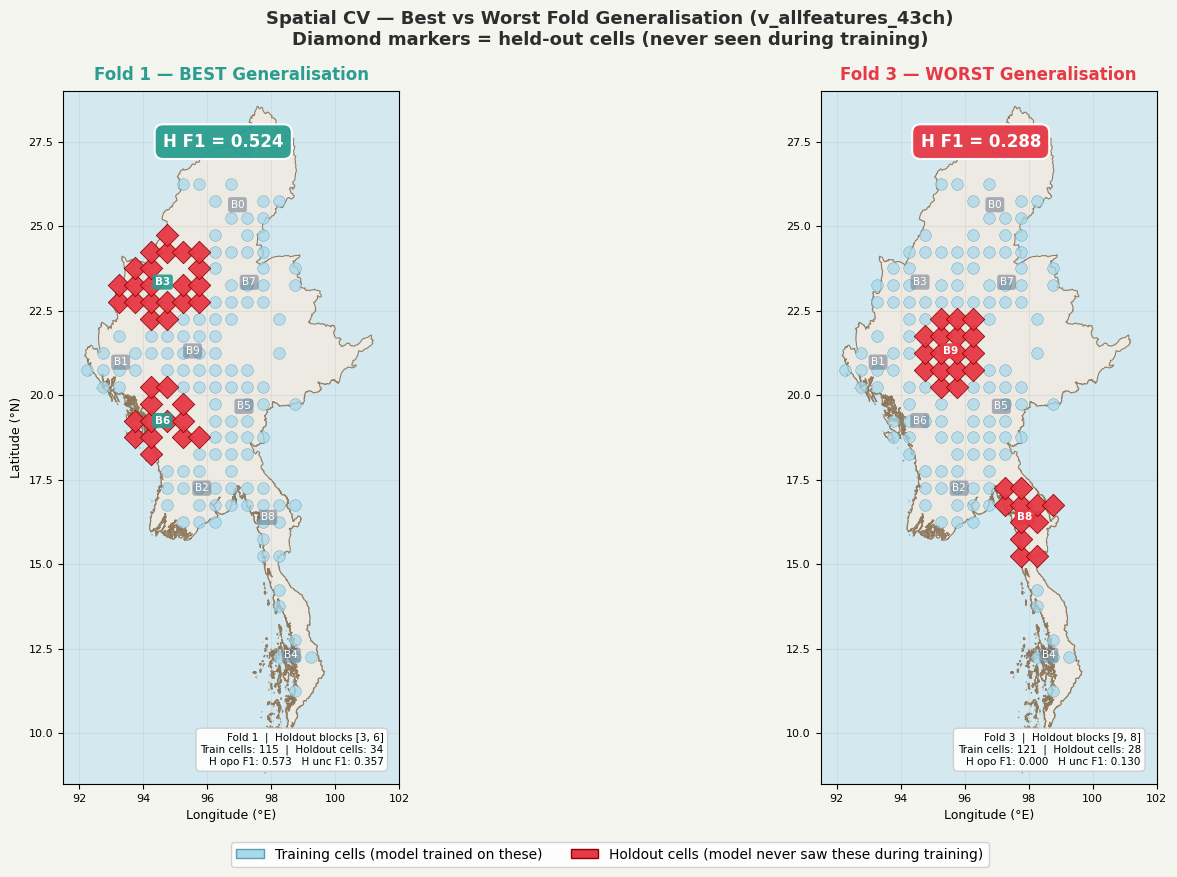


✅ Map saved → best_worst_fold_map.png

Best fold (Fold 1, H F1=0.524): model generalises well here
Worst fold (Fold 3, H F1=0.288): model struggles here


In [25]:
# ── CELL 6: Best vs Worst Fold Map ────────────────────────────────────────────
import geopandas as gpd, matplotlib.pyplot as plt
import matplotlib.patches as mpatches, matplotlib.patheffects as pe
from matplotlib.gridspec import GridSpec

# ── Load results and find best/worst fold for the reference model ─────────────
cv_df  = pd.read_csv(DATA_PROC / "spatial_cv_comparison" / "spatial_cv_final.csv")
model  = "v_allfeatures_43ch"                              # reference model for fold comparison
mdf    = cv_df[cv_df["model"] == model].sort_values("fold").reset_index(drop=True)

best_fold  = int(mdf.loc[mdf["h_macro_f1"].idxmax(), "fold"])  # highest H F1
worst_fold = int(mdf.loc[mdf["h_macro_f1"].idxmin(), "fold"])  # lowest H F1
best_f1    = float(mdf[mdf["fold"]==best_fold ]["h_macro_f1"].values[0])  # ← .values[0] fixes Series
worst_f1   = float(mdf[mdf["fold"]==worst_fold]["h_macro_f1"].values[0])

print(f"Model: {model}")
print(f"Best fold:  Fold {best_fold}  →  H F1 = {best_f1:.3f}  "
      f"(holdout blocks {FOLD_ASSIGNMENTS[best_fold]})")
print(f"Worst fold: Fold {worst_fold} →  H F1 = {worst_f1:.3f}  "
      f"(holdout blocks {FOLD_ASSIGNMENTS[worst_fold]})")

# ── Load Myanmar admin boundary ───────────────────────────────────────────────
gadm_path = PROJECT_ROOT / "data" / "raw" / "gadm" / "gadm41_MMR.gpkg"
myanmar   = gpd.read_file(gadm_path, layer=0).to_crs("EPSG:4326")

# ── Build roles (training vs holdout) for each fold ──────────────────────────
def get_roles(fold_id):
    holdout_blocks = FOLD_ASSIGNMENTS[fold_id]             # blocks held out
    return {gid: "holdout" if gid_to_block[gid] in holdout_blocks else "training"
            for gid in gid_to_block}                       # dict: gid → role

roles_best  = get_roles(best_fold)
roles_worst = get_roles(worst_fold)
plot_df = gid_coords[gid_coords["priogrid_gid"].isin(gid_to_block.keys())].copy()
plot_df["role_best"]  = plot_df["priogrid_gid"].map(roles_best)
plot_df["role_worst"] = plot_df["priogrid_gid"].map(roles_worst)

# ── Plot ──────────────────────────────────────────────────────────────────────
COLORS = {"training": "#A8D8EA", "holdout": "#E63946"}
fig = plt.figure(figsize=(16, 9), facecolor="#F5F5F0")
fig.suptitle(
    f"Spatial CV — Best vs Worst Fold Generalisation ({model})\n"
    f"Diamond markers = held-out cells (never seen during training)",
    fontsize=13, fontweight="bold", y=0.97, color="#2D2D2D"
)
gs = GridSpec(1, 2, figure=fig, wspace=0.06, left=0.04, right=0.96)

for col, (fold_id, role_col, fold_f1, tag, accent) in enumerate([
    (best_fold,  "role_best",  best_f1,  "BEST",  "#2A9D8F"),
    (worst_fold, "role_worst", worst_f1, "WORST", "#E63946"),
]):
    ax = fig.add_subplot(gs[col])
    ax.set_facecolor("#D4E8F0")
    myanmar.plot(ax=ax, color="#F0EBE3", edgecolor="#8B7355", linewidth=0.8, alpha=0.9)

    tr = plot_df[plot_df[role_col]=="training"]
    ho = plot_df[plot_df[role_col]=="holdout"]
    ax.scatter(tr["lon"], tr["lat"], c=COLORS["training"],
               s=70, alpha=0.75, zorder=3, edgecolors="#5A9FB5", linewidths=0.4)
    ax.scatter(ho["lon"], ho["lat"], c=COLORS["holdout"],
               s=130, alpha=0.95, zorder=5, edgecolors="#8B0000",
               linewidths=0.6, marker="D")

    # Block labels
    for b in range(K_PIECES):
        bc = gid_coords[gid_coords["block"]==b]
        cx, cy = bc["lon"].mean(), bc["lat"].mean()
        is_ho  = b in FOLD_ASSIGNMENTS[fold_id]
        ax.text(cx, cy, f"B{b}", fontsize=7.5, ha="center", va="center",
                fontweight="bold" if is_ho else "normal",
                color="white", zorder=7,
                bbox=dict(boxstyle="round,pad=0.25",
                          facecolor=accent if is_ho else "#607080",
                          alpha=0.92 if is_ho else 0.5, edgecolor="none"))

    # Metrics from the CSV — use .values[0] throughout to avoid Series
    h_opo = float(mdf[mdf["fold"]==fold_id]["h_opo_f1"].values[0])
    h_unc = float(mdf[mdf["fold"]==fold_id]["h_unc_f1"].values[0])
    n_ho  = len(ho); n_tr = len(tr)

    # Performance badge
    ax.text(96.5, 27.5, f"H F1 = {fold_f1:.3f}",
            fontsize=12, fontweight="bold", ha="center", va="center",
            color="white", zorder=10,
            bbox=dict(boxstyle="round,pad=0.5", facecolor=accent,
                      edgecolor="white", linewidth=1.5, alpha=0.95))

    # Info box
    info = (f"Fold {fold_id}  |  Holdout blocks {FOLD_ASSIGNMENTS[fold_id]}\n"
            f"Train cells: {n_tr}  |  Holdout cells: {n_ho}\n"
            f"H opo F1: {h_opo:.3f}   H unc F1: {h_unc:.3f}")
    ax.text(101.5, 9.0, info, fontsize=7.5, ha="right", va="bottom",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white",
                      edgecolor="#CCCCCC", alpha=0.93))

    ax.set_title(f"Fold {fold_id} — {tag} Generalisation",
                 fontsize=12, fontweight="bold", color=accent, pad=8)
    ax.set_xlim(91.5, 102); ax.set_ylim(8.5, 29)
    ax.set_xlabel("Longitude (°E)", fontsize=9)
    ax.set_ylabel("Latitude (°N)" if col==0 else "", fontsize=9)
    ax.tick_params(labelsize=8); ax.grid(alpha=0.15, color="#999999")

legend_elements = [
    mpatches.Patch(facecolor=COLORS["training"], edgecolor="#5A9FB5",
                   label="Training cells (model trained on these)"),
    mpatches.Patch(facecolor=COLORS["holdout"],  edgecolor="#8B0000",
                   label="Holdout cells (model never saw these during training)"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=2,
           fontsize=10, framealpha=0.9, bbox_to_anchor=(0.5, 0.01))
plt.savefig(PROJECT_ROOT / "reports/figures/best_worst_fold_map.png",
            dpi=180, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"\n✅ Map saved → best_worst_fold_map.png")
print(f"\nBest fold (Fold {best_fold}, H F1={best_f1:.3f}): model generalises well here")
print(f"Worst fold (Fold {worst_fold}, H F1={worst_f1:.3f}): model struggles here")

## Notebook 05 — Complete Analysis: 19-Model Spatial CV (95 Training Runs)

### The complete spatial holdout ranking

Five model families tested across 95 training runs:

| Rank | Model | H F1 | Δ F1 | H opo | H unc |
|---|---|---|---|---|---|
| 1 | **v_allfeatures_43ch_frozen_lj** | **0.464**±0.052 | **−0.475** | 0.387 | 0.349 |
| 2 | v1_frozen_10ch_lj | 0.419±0.067 | −0.503 | 0.317 | 0.354 |
| 3 | v1_frozen_10ch | 0.414±0.096 | −0.486 | 0.350 | 0.306 |
| 4 | v_allfeatures_43ch | 0.407±0.103 | −0.528 | 0.316 | 0.244 |
| 5 | v_nofrozen_10ch | 0.405±0.094 | −0.508 | 0.317 | 0.264 |
| 6 | v_allfeatures_43ch_lj | 0.402±0.086 | −0.540 | 0.270 | 0.266 |
| 7 | v_nofrozen_terrain | 0.396±0.069 | −0.520 | 0.363 | 0.226 |
| 8 | v_allfeatures_43ch_frozen | 0.389±0.083 | −0.541 | 0.338 | 0.213 |
| 9–11 | terrain variants | 0.374–0.382 | | | |
| 12–15 | Felipe (focal) | 0.298–0.322 | | | |
| 16–19 | Felipe + terrain | 0.252–0.335 | | | |

### Finding 1: The frozen encoder + left-join + 43 features combination breaks the spatial ceiling

The previous ceiling was 0.419 (v1_frozen_10ch_lj). v_allfeatures_43ch_frozen_lj
achieves H F1=0.464 — an improvement of 4.5pp over the previous best and
11pp over the discriminative-LR version of the same feature set.

Three mechanisms combine to produce this result:
1. **43 UCDP features** provide rich conflict-actor signal enabling high NH F1 (0.939)
2. **Frozen encoder (Phase 1/2)** prevents the encoder from memorising Myanmar's
   specific geographic patterns during the critical early training phase
3. **Left-join data (185 cells)** adds 36 geographically diverse quiet cells
   (0 UCDP events, real Wikipedia labels) that train the decoder to predict
   stable labels without conflict signals — making the model robust to new
   regions with different conflict intensities

The key insight: frozen encoder alone (v_allfeatures_43ch_frozen, H F1=0.389)
actually hurts compared to discriminative LR (v_allfeatures_43ch, H F1=0.407).
The frozen encoder only helps when combined with LJ data. Without the extra
quiet cells, the frozen Phase 1 leaves the decoder undertrained and the model
cannot fully exploit the 43-feature signal.

### Finding 2: Lowest fold variance in the entire experiment

| Model | Fold 0 | Fold 1 | Fold 2 | Fold 3 | Fold 4 | Fold st. dev. |
|---|---:|---:|---:|---:|---:|---:|
| `v_allfeatures_43ch_frozen_lj` | 0.418 | 0.500 | 0.521 | 0.400 | 0.479 | 0.052 |
| `v1_frozen_10ch_lj` | 0.324 | 0.478 | 0.481 | 0.429 | 0.382 | 0.067 |
| `v1_frozen_10ch` | 0.383 | 0.505 | 0.525 | 0.310 | 0.348 | 0.096 |

Fold 3 (Central Myanmar, 89% government cells, previously the hardest fold)
improves from 0.288–0.310 to 0.400. The combined frozen+LJ approach prevents
the complete collapse that other models experience in government-dominated
regions.

### Finding 3: The best vs worst fold reveals the structural reason for the ceiling

For v_allfeatures_43ch:
- **Best: Fold 1 (H F1=0.524)** — holdout blocks 3 and 6: contested western Myanmar
  (Sagaing/Chin). Block 3 contains gov=245, opo=148, uncertain=206. The model
  transfers mixed-conflict representations successfully.
- **Worst: Fold 3 (H F1=0.288)** — holdout blocks 9 and 8: central and southern
  Myanmar. Block 9 is 89% government (gov=428, opo=4). No opposition pattern
  exists to transfer.

v_allfeatures_43ch_frozen_lj raises the Fold 3 score to 0.400, the largest
improvement for this hardest fold. The quiet cells and frozen encoder together
teach the model that "government" is a valid prediction even without positive
conflict evidence — reducing over-confidence in opposition predictions for
unfamiliar regions.

### The definitive spatial CV ranking (top 8)

| Rank | Model | Family | H F1 | H opo |
|---|---|---|---|---|
| 1 | v_allfeatures_43ch_frozen_lj | 43ch + frozen + LJ | **0.464** | 0.387 |
| 2 | v1_frozen_10ch_lj | 10ch + frozen + LJ | 0.419 | 0.317 |
| 3 | v1_frozen_10ch | 10ch + frozen | 0.414 | **0.350** |
| 4 | v_allfeatures_43ch | 43ch + discrim | 0.407 | 0.316 |
| 5 | v_nofrozen_10ch | 10ch + discrim | 0.405 | 0.317 |
| 6 | v_allfeatures_43ch_lj | 43ch + discrim + LJ | 0.402 | 0.270 |
| 7 | v_nofrozen_terrain | 10ch + discrim + terrain | 0.396 | 0.363 |
| 8 | v_allfeatures_43ch_frozen | 43ch + frozen (no LJ) | 0.389 | 0.338 |

Terrain variants: 0.374–0.396 | Felipe focal: 0.252–0.335